# 05 — Portfolio Selection

Top-N HRP portfolio: comparison of N=5 vs N=7, live weights, and diagnostics.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

from src.data import load_prices, compute_returns
from src.signals import load_signals
from src.portfolio import (
    run_n_comparison, current_portfolio,
    build_weight_matrix,
)
from src.hypothesis_tests import compute_me_forward_returns, _run_backtest, _metrics

plt.rcParams.update({'figure.dpi': 120})
PROC = '../data/processed'

prices  = load_prices(PROC)
returns = compute_returns(prices)
signals = load_signals(PROC)

me_returns  = prices.resample('ME').last().pct_change()
fwd_returns = compute_me_forward_returns(prices)

print('Data loaded.')

Data loaded.


## 1. Top-5 vs Top-7 — performance comparison


  Portfolio selection comparison (HRP weights)
                Top-5    Top-7
Ann Return %    7.380    7.370
Ann Vol %      10.300    9.300
Sharpe          0.716    0.793
Max DD %      -18.320  -15.020
Calmar          0.403    0.491
N months      199.000  199.000


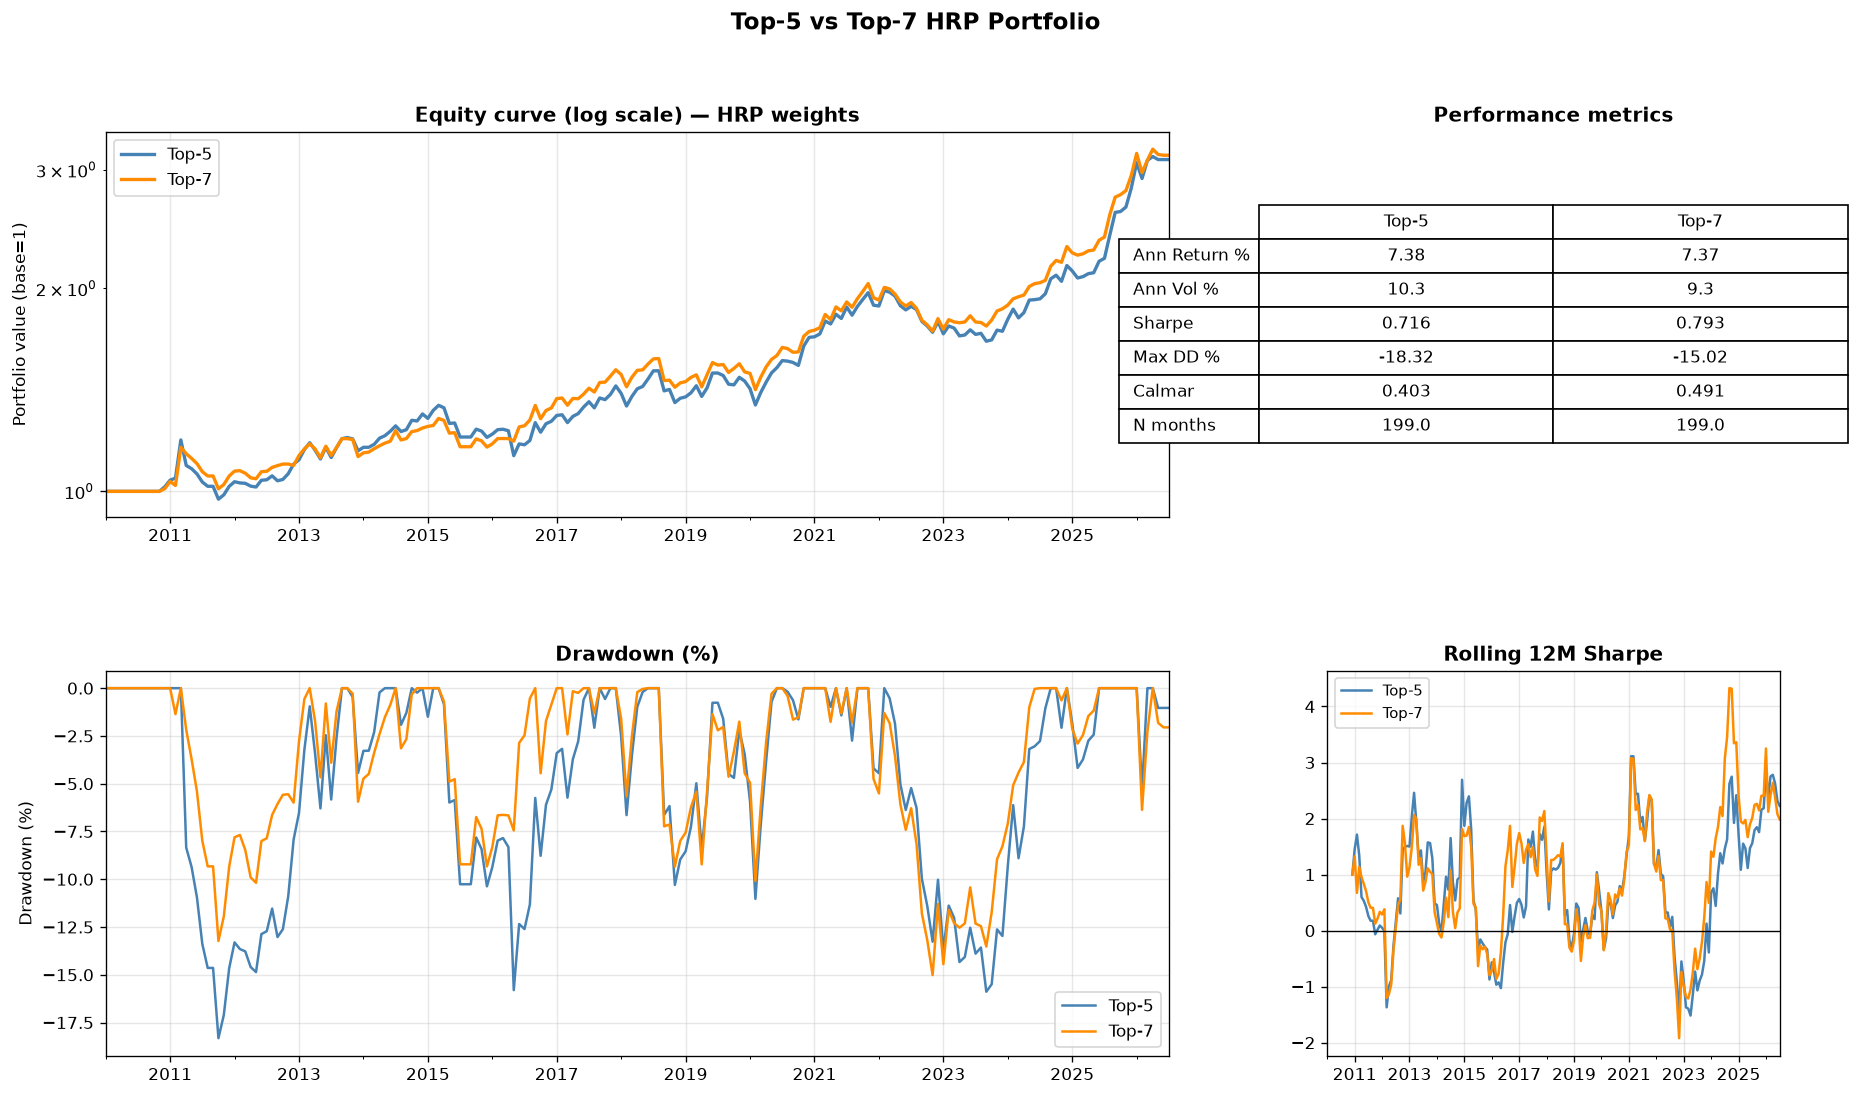

In [2]:
results = run_n_comparison(signals, prices, method='hrp', ns=[5, 7])
colors  = {'Top-5': 'steelblue', 'Top-7': 'darkorange'}

fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Equity curves
ax = fig.add_subplot(gs[0, :2])
for label, res in results.items():
    eq = (1 + res['returns']).cumprod()
    eq.plot(ax=ax, label=label, color=colors[label], linewidth=2)
ax.set_yscale('log')
ax.set_title('Equity curve (log scale) — HRP weights', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylabel('Portfolio value (base=1)')

# Metrics table
ax = fig.add_subplot(gs[0, 2])
ax.axis('off')
m_df = pd.DataFrame({k: v['metrics'] for k, v in results.items()})
tbl  = ax.table(cellText=m_df.round(3).values,
                rowLabels=m_df.index, colLabels=m_df.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.7)
ax.set_title('Performance metrics', fontweight='bold')

# Drawdowns
ax = fig.add_subplot(gs[1, :2])
for label, res in results.items():
    eq = (1 + res['returns']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    dd.plot(ax=ax, label=label, color=colors[label], linewidth=1.5)
ax.set_title('Drawdown (%)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylabel('Drawdown (%)')

# Rolling 12M Sharpe
ax = fig.add_subplot(gs[1, 2])
for label, res in results.items():
    r = res['returns']
    roll_sharpe = (r.rolling(12).mean() / r.rolling(12).std() * np.sqrt(12))
    roll_sharpe.plot(ax=ax, label=label, color=colors[label], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rolling 12M Sharpe', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Top-5 vs Top-7 HRP Portfolio', fontsize=14, fontweight='bold')
plt.show()

## 2. Live portfolio — current month-end

In [3]:
table = current_portfolio(signals, prices, n_top=5, method='hrp')


  LIVE PORTFOLIO  —  2026-07-31  —  Top-5 HRP
  Universe: 15 ETFs  |  Eligible: 12 (price > 200DMA)  |  Selected: 5

─────────────────────────────────────────────────────────────────
      Ticker   Score  3M %  6M %  12M %  Vol % pa Eligible  Weight %      Status
Rank                                                                            
1     HKOR.L  1.3319  59.5  96.6  184.6      60.1      YES      4.47    SELECTED
2     HTWN.L  0.8392  54.6  71.3  103.2      34.0      YES     10.80    SELECTED
3     EQQQ.L  0.2969  28.7  19.4   36.3      17.8      YES     11.45    SELECTED
4     IJPN.L  0.2420  13.3  17.1   32.8      20.1      YES     52.71    SELECTED
5     VUSA.L  0.1889  16.6  10.6   24.8      10.6      YES     20.56    SELECTED
6     HCAN.L  0.1719   6.4   7.0   27.6       8.6      YES      0.00  RANKED OUT
7     IWDA.L  0.1593  15.1   8.5   20.7      13.8      YES      0.00  RANKED OUT
8     WNRG.L  0.1508 -15.9  17.5   26.0      26.8      YES      0.00  RANKED OUT
9     

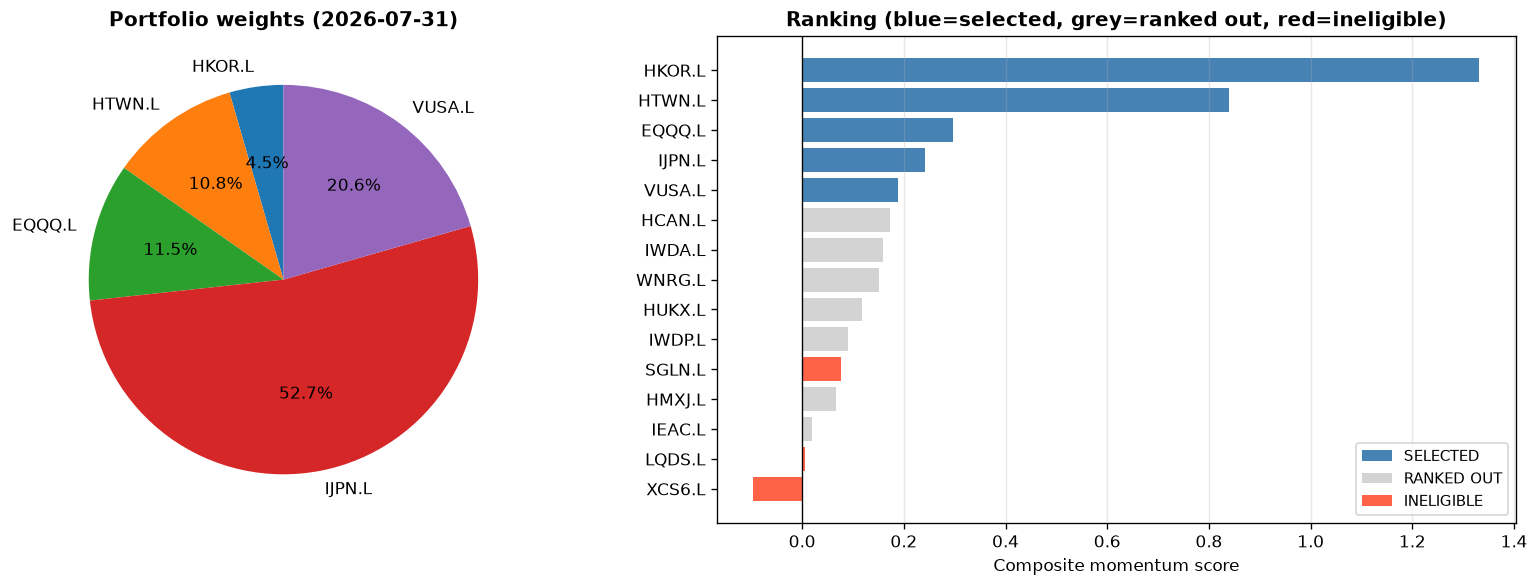

In [4]:
selected = table[table['Status'] == 'SELECTED']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight pie
ax = axes[0]
ax.pie(selected['Weight %'], labels=selected['Ticker'],
       autopct='%1.1f%%', startangle=90,
       colors=plt.cm.tab10.colors[:len(selected)])
ax.set_title(f'Portfolio weights ({signals["score"].index[-1].date()})', fontweight='bold')

# Score bar — all assets, colour by status
ax = axes[1]
status_colors = {'SELECTED': 'steelblue', 'RANKED OUT': 'lightgrey', 'INELIGIBLE': 'tomato'}
bar_colors = [status_colors[s] for s in table['Status']]
bars = ax.barh(table['Ticker'][::-1], table['Score'][::-1], color=bar_colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Composite momentum score')
ax.set_title('Ranking (blue=selected, grey=ranked out, red=ineligible)', fontweight='bold')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l, c in status_colors.items()]
ax.legend(handles=legend_elems, fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Weight history — how often is each ETF selected?

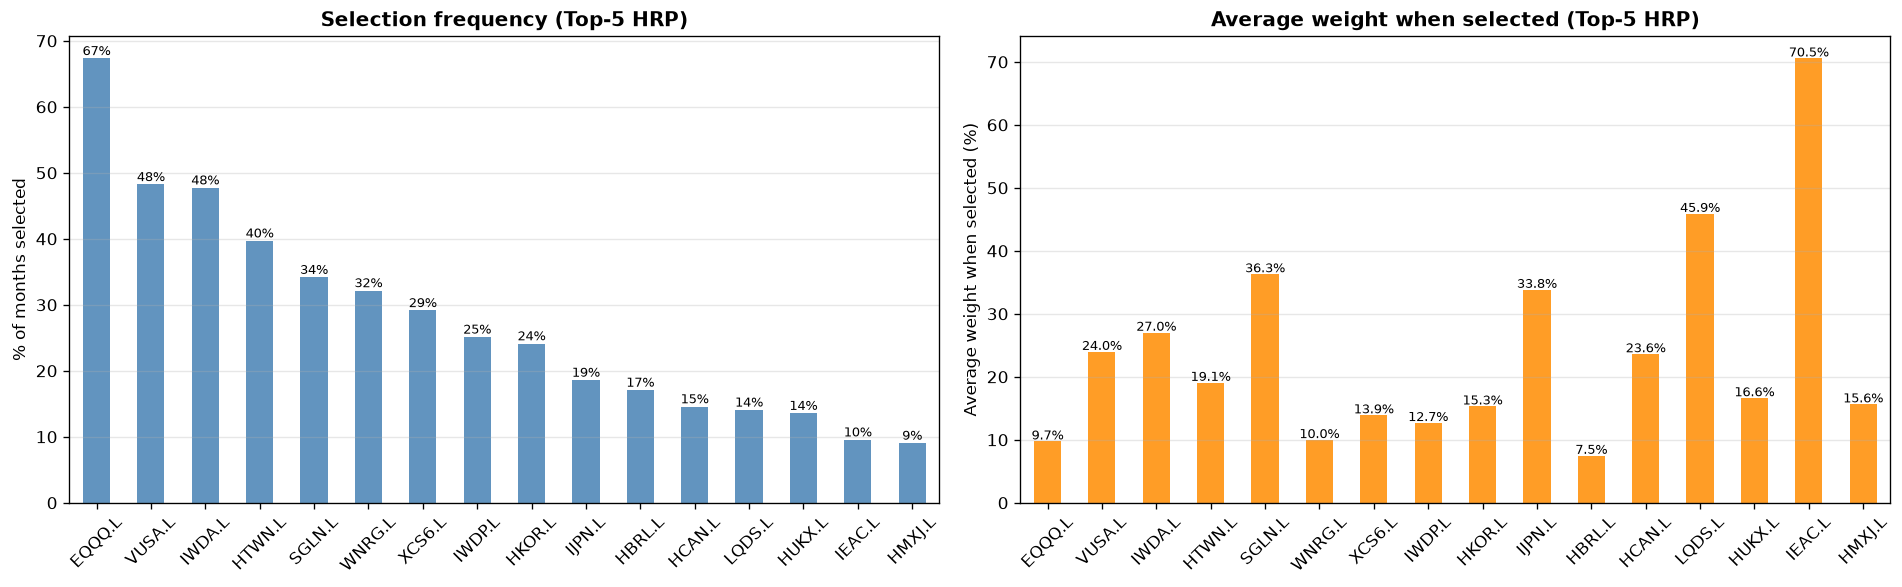

In [5]:
w5 = build_weight_matrix(signals, me_returns, n_top=5, method='hrp')

# Selection frequency
freq = (w5 > 0).mean().sort_values(ascending=False) * 100
avg_w = w5[w5 > 0].mean().reindex(freq.index) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
freq.plot.bar(ax=ax, color='steelblue', alpha=0.85)
ax.set_ylabel('% of months selected')
ax.set_title('Selection frequency (Top-5 HRP)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(freq):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

ax = axes[1]
avg_w.plot.bar(ax=ax, color='darkorange', alpha=0.85)
ax.set_ylabel('Average weight when selected (%)')
ax.set_title('Average weight when selected (Top-5 HRP)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(avg_w):
    if not np.isnan(v):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Weight allocation over time

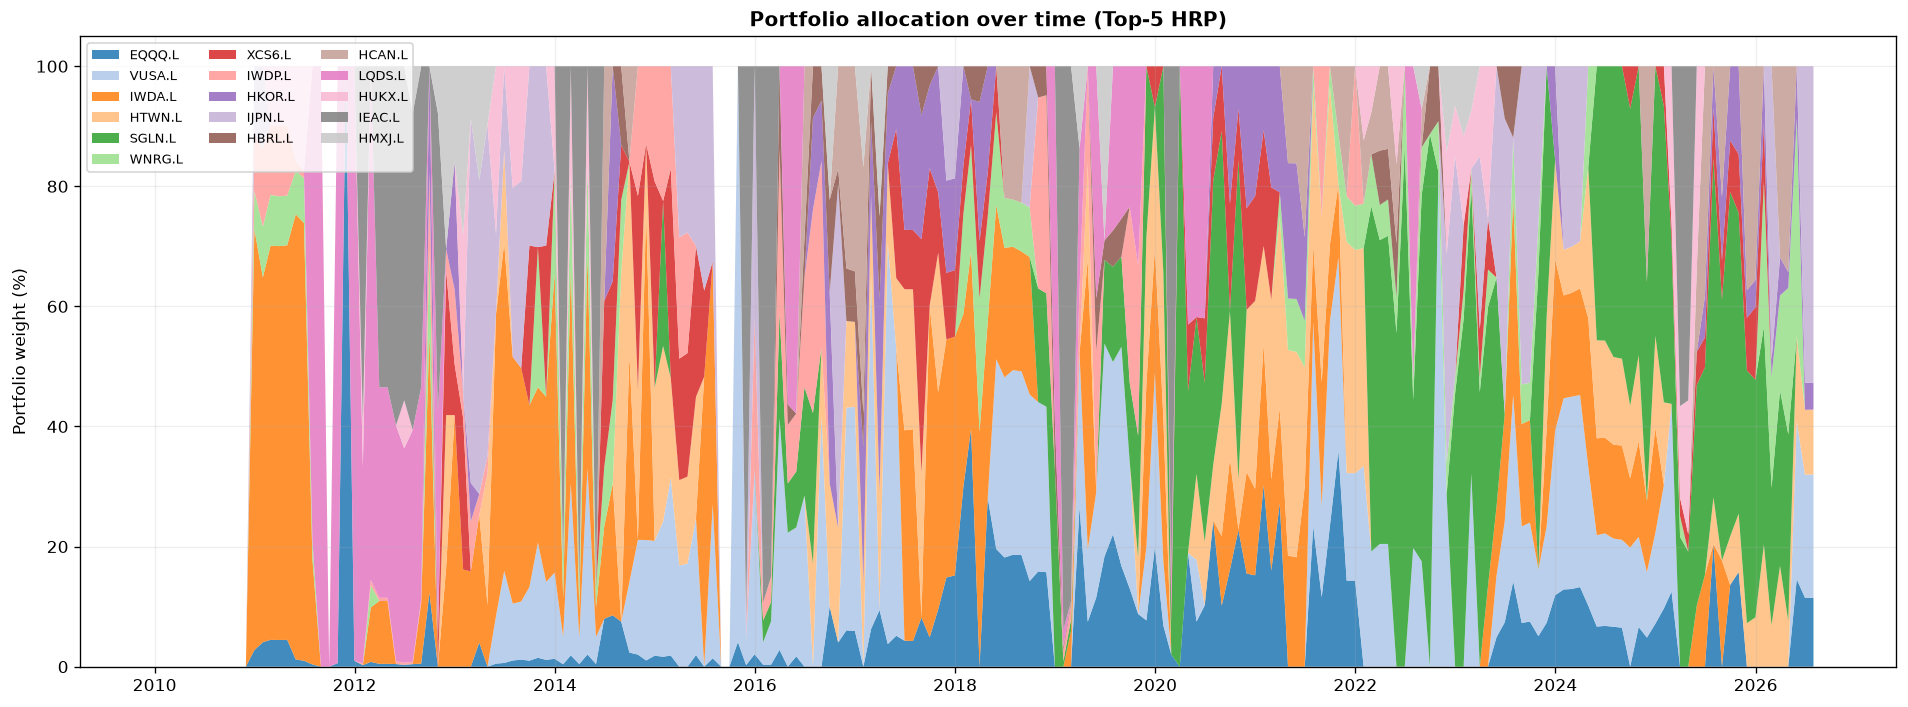

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

tickers_by_freq = freq.index.tolist()
w_plot = w5[tickers_by_freq] * 100

ax.stackplot(w_plot.index, w_plot.T.values,
             labels=tickers_by_freq,
             colors=plt.cm.tab20.colors[:len(tickers_by_freq)],
             alpha=0.85)

ax.set_ylabel('Portfolio weight (%)')
ax.set_ylim(0, 105)
ax.set_title('Portfolio allocation over time (Top-5 HRP)', fontweight='bold', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Monthly turnover

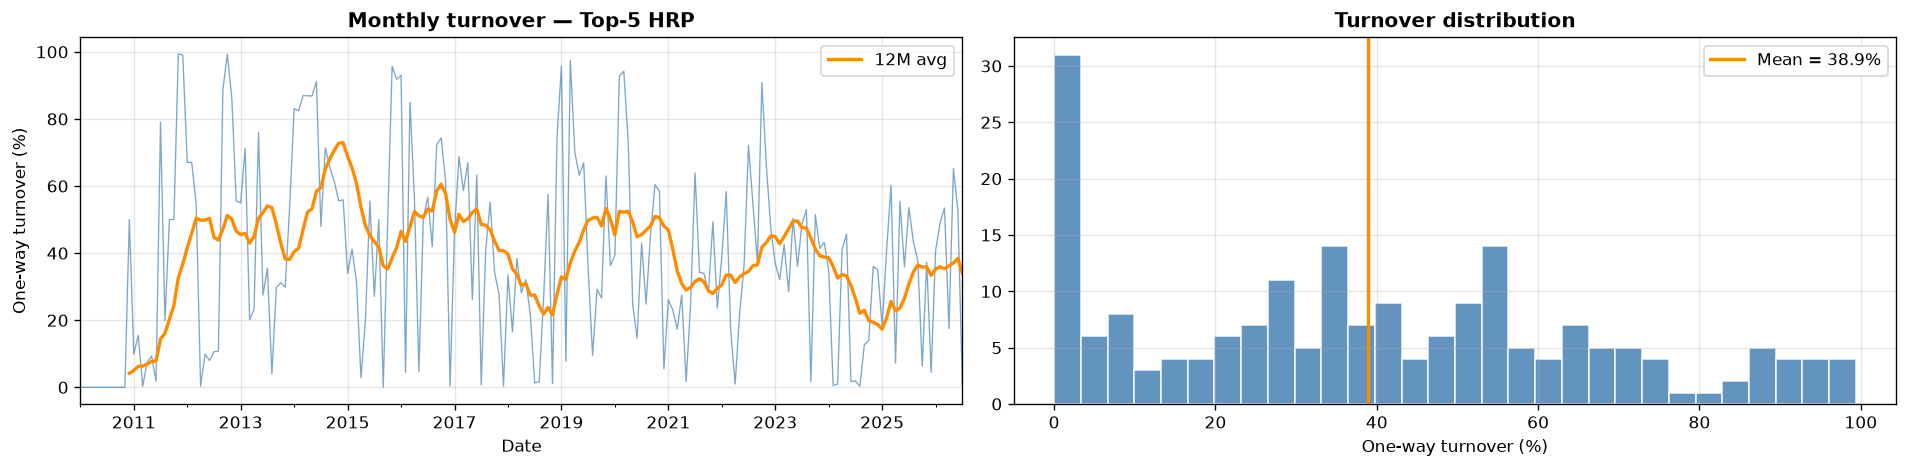

Average monthly one-way turnover : 38.9%
Annualised two-way turnover      : 934%
At 10bp cost: drag ≈ 0.47% per year


In [7]:
# Compute turnover from weight changes
prev = pd.Series(0.0, index=w5.columns)
turnovers = []
for dt in w5.index:
    w = w5.loc[dt].fillna(0.0)
    turnovers.append((w - prev).abs().sum() / 2.0)
    fwd = fwd_returns.loc[dt].reindex(w.index).fillna(0.0) if dt in fwd_returns.index else pd.Series(0.0, index=w.index)
    drifted = w * (1 + fwd)
    s = drifted.sum()
    prev = drifted / s if s > 0 else w

to_series = pd.Series(turnovers, index=w5.index) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
to_series.plot(ax=ax, color='steelblue', linewidth=0.8, alpha=0.7)
to_series.rolling(12).mean().plot(ax=ax, color='darkorange', linewidth=2, label='12M avg')
ax.set_ylabel('One-way turnover (%)')
ax.set_title('Monthly turnover — Top-5 HRP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(to_series, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(to_series.mean(), color='darkorange', linewidth=2, label=f'Mean = {to_series.mean():.1f}%')
ax.set_xlabel('One-way turnover (%)')
ax.set_title('Turnover distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Average monthly one-way turnover : {to_series.mean():.1f}%')
print(f'Annualised two-way turnover      : {to_series.mean()*2*12:.0f}%')
print(f'At 10bp cost: drag ≈ {to_series.mean()/100 * 0.001 * 12 * 100:.2f}% per year')

## 6. Concentration — why not top-1, why not all?

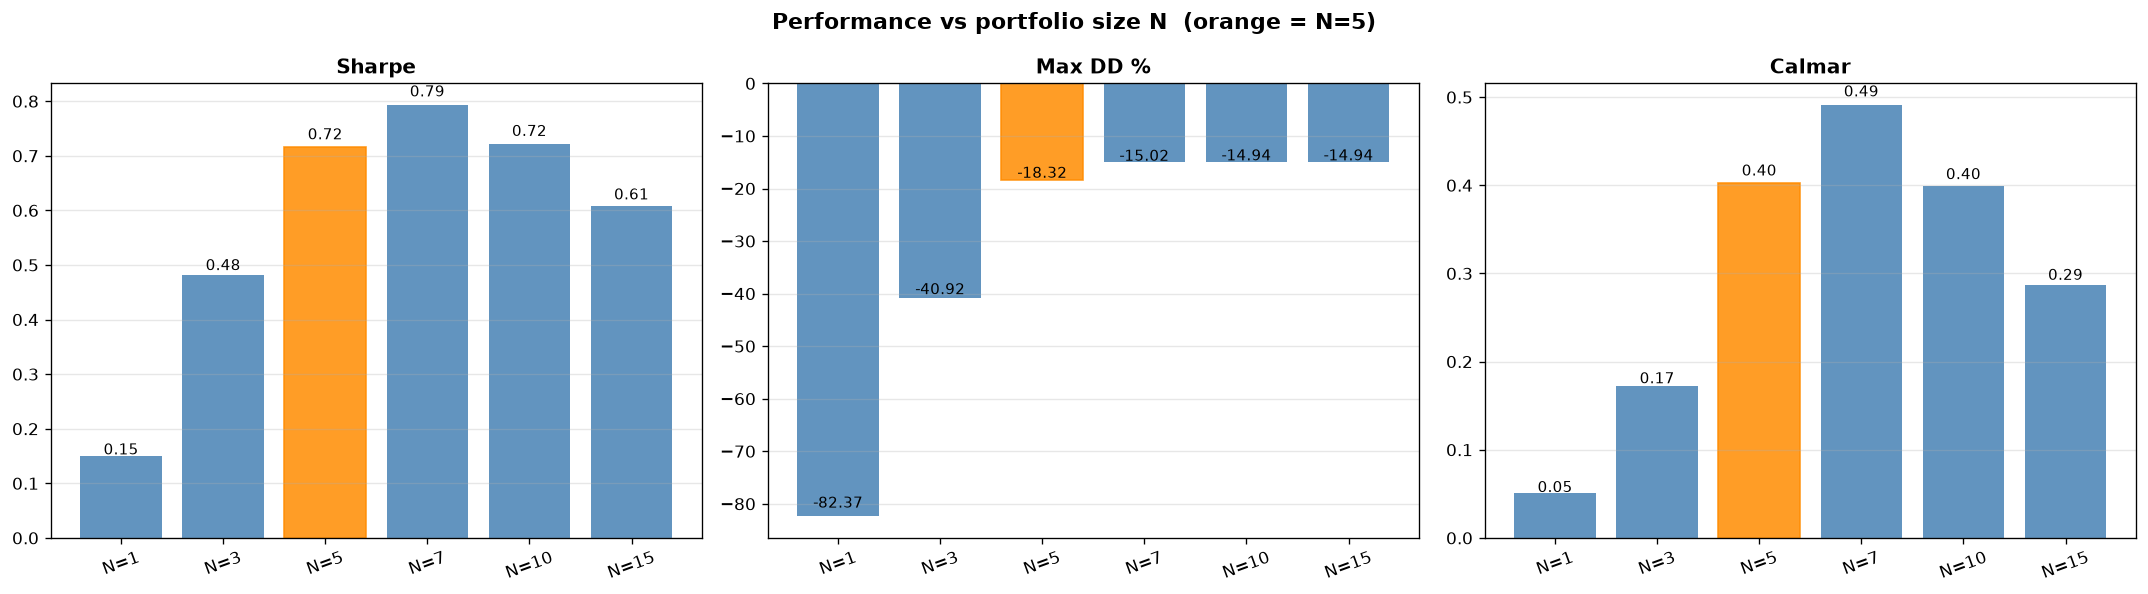


Full metrics by N:
                  N=1      N=3      N=5      N=7     N=10     N=15
Ann Return %    4.200    7.050    7.380    7.370    5.960    4.280
Ann Vol %      27.970   14.660   10.300    9.300    8.250    7.040
Sharpe          0.150    0.481    0.716    0.793    0.722    0.608
Max DD %      -82.370  -40.920  -18.320  -15.020  -14.940  -14.940
Calmar          0.051    0.172    0.403    0.491    0.399    0.287
N months      199.000  199.000  199.000  199.000  199.000  199.000


In [8]:
all_results = {}
for n in [1, 3, 5, 7, 10, 15]:
    w_df = build_weight_matrix(signals, me_returns, n_top=n, method='hrp')
    ret  = _run_backtest(w_df, fwd_returns).dropna()
    all_results[f'N={n}'] = _metrics(ret)

m_all = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['Sharpe', 'Max DD %', 'Calmar']):
    vals = m_all.loc[metric]
    bars = ax.bar(vals.index, vals, color='steelblue', alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(bar.get_height())*0.02,
                f'{v:.2f}', ha='center', fontsize=9)

    # Highlight N=5
    idx = list(vals.index).index('N=5')
    bars[idx].set_color('darkorange')

plt.suptitle('Performance vs portfolio size N  (orange = N=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFull metrics by N:')
print(m_all.to_string())